data engineering
loss function
model
train test split

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [141]:
df = pd.read_csv('student_performance.csv')
df

,Unnamed: 0,age,study_time,failures,family_support,extra_educational_support,internet,romantic,free_time,going_out,health,absences,G1,G2,G3
0,0,17,2,2,no,no,yes,yes,1,4,3,1,5,7,3.1
1,1,18,3,3,no,yes,yes,yes,3,5,4,2,5,12,7.2
2,2,15,1,1,no,yes,yes,yes,3,1,4,5,17,14,16.4
3,3,17,1,3,no,yes,yes,no,4,3,2,2,9,17,12.4
4,4,17,1,3,yes,no,no,yes,5,5,5,9,8,16,9.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,15,1,0,no,yes,no,no,5,3,2,18,7,17,14.2
996,996,15,2,2,no,no,yes,no,4,2,1,5,7,17,11.0
997,997,18,1,0,no,yes,no,yes,3,2,5,17,9,14,13.5
998,998,18,3,1,no,no,no,yes,1,4,2,9,15,6,11.1


In [142]:
features_column = ['family_support','study_time', 'failures', 'G1', 'G2', 'G3']
df = df[features_column]
df

,family_support,study_time,failures,G1,G2,G3
0,no,2,2,5,7,3.1
1,no,3,3,5,12,7.2
2,no,1,1,17,14,16.4
3,no,1,3,9,17,12.4
4,yes,1,3,8,16,9.8
...,...,...,...,...,...,...
995,no,1,0,7,17,14.2
996,no,2,2,7,17,11.0
997,no,1,0,9,14,13.5
998,no,3,1,15,6,11.1


## data engineering

In [143]:
df['family_support'] = df['family_support'].map({'yes': 1, 'no': 0})
df

,family_support,study_time,failures,G1,G2,G3
0,0,2,2,5,7,3.1
1,0,3,3,5,12,7.2
2,0,1,1,17,14,16.4
3,0,1,3,9,17,12.4
4,1,1,3,8,16,9.8
...,...,...,...,...,...,...
995,0,1,0,7,17,14.2
996,0,2,2,7,17,11.0
997,0,1,0,9,14,13.5
998,0,3,1,15,6,11.1


In [144]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


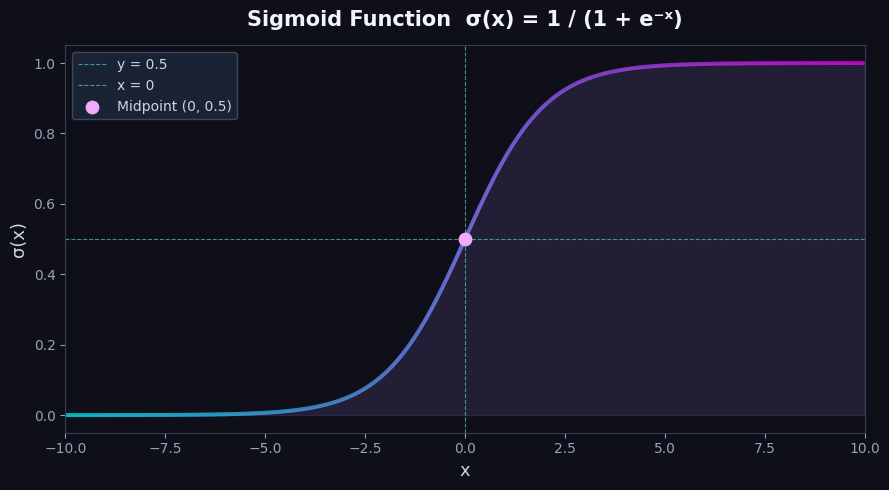

Graph saved as sigmoid_plot.png


In [145]:
# ── Sigmoid function ──────────────────────────────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ── Generate data ─────────────────────────────────────────────────
x = np.linspace(-10, 10, 3000)
y = sigmoid(x)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

# Gradient-style line using a colormap
from matplotlib.collections import LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='cool', linewidth=2.8)
lc.set_array(x)
ax.add_collection(lc)

# Fill under the curve
ax.fill_between(x, y, alpha=0.12, color='#a78bfa')

# Reference lines
ax.axhline(0.5, color='#6ee7b7', linewidth=0.8, linestyle='--', alpha=0.6, label='y = 0.5')
ax.axvline(0,   color='#6ee7b7', linewidth=0.8, linestyle='--', alpha=0.6, label='x = 0')

# Highlight the midpoint
ax.scatter([0], [0.5], color='#f0abfc', s=80, zorder=5, label='Midpoint (0, 0.5)')

# Labels & style
ax.set_xlim(-10, 10)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('x', color='#cbd5e1', fontsize=13)
ax.set_ylabel('σ(x)', color='#cbd5e1', fontsize=13)
ax.set_title('Sigmoid Function  σ(x) = 1 / (1 + e⁻ˣ)',
             color='#f1f5f9', fontsize=15, fontweight='bold', pad=14)

ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

ax.legend(facecolor='#1e293b', edgecolor='#475569',
          labelcolor='#cbd5e1', fontsize=10)

plt.tight_layout()
plt.savefig('sigmoid_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved as sigmoid_plot.png")

In [146]:
x = df[['G2']]
y = df['pass_fail']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [147]:
x_train


,G2
29,7
535,12
695,17
557,17
836,7
...,...
106,13
270,8
860,7
435,14


In [148]:
y_train

29     0
535    1
695    1
557    1
836    1
      ..
106    0
270    1
860    0
435    0
102    1
Name: pass_fail, Length: 800, dtype: int64

In [149]:
model = LogisticRegression()
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [150]:
model.coef_, model.intercept_

(array([[0.28497567]]), array([-2.13402016]))

In [151]:
model.predict(np.array([[10]]).reshape(1, -1))

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

## Accuracy

In [152]:
y_hat = model.predict(x_test)
(y_hat == y_test).astype(int).sum() / len(y_test)

np.float64(0.75)

## Decision Boundary

In [153]:
from sklearn.metrics import accuracy_score


y_pred = model.predict(x_train)
acc = accuracy_score(y_train, y_pred)
boundary = -model.intercept_[0] / model.coef_[0][0]

print(boundary)

7.488429354501466


In [154]:
y_hat

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1])

In [155]:
y_hat = model.predict_proba(x_test)
y_hat

array([[0.32833252, 0.67166748],
       [0.67021151, 0.32978849],
       [0.60447974, 0.39552026],
       [0.08124199, 0.91875801],
       [0.08124199, 0.91875801],
       [0.60447974, 0.39552026],
       [0.67021151, 0.32978849],
       [0.21658358, 0.78341642],
       [0.10521149, 0.89478851],
       [0.67021151, 0.32978849],
       [0.39394466, 0.60605534],
       [0.67021151, 0.32978849],
       [0.21658358, 0.78341642],
       [0.67021151, 0.32978849],
       [0.17212182, 0.82787818],
       [0.53474155, 0.46525845],
       [0.32833252, 0.67166748],
       [0.26880142, 0.73119858],
       [0.06235274, 0.93764726],
       [0.60447974, 0.39552026],
       [0.26880142, 0.73119858],
       [0.17212182, 0.82787818],
       [0.10521149, 0.89478851],
       [0.21658358, 0.78341642],
       [0.46361812, 0.53638188],
       [0.60447974, 0.39552026],
       [0.13521215, 0.86478785],
       [0.39394466, 0.60605534],
       [0.32833252, 0.67166748],
       [0.46361812, 0.53638188],
       [0.

## Multiple Features

In [156]:
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


In [157]:
x = df[['family_support', 'study_time', 'failures', 'G1', 'G2',]]
y = df['pass_fail']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [158]:
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


In [159]:
model = LogisticRegression()
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [160]:
y_hat = model.predict(x_test)
(y_hat == y_test).astype(int).sum() / len(y_test)

accuracy_score(y_test, y_hat)

0.895

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, \
    log_loss, f1_score, precision_score, recall_score,precision_recall_curve,\
    precision_recall_fscore_support

In [162]:
confusion_matrix(y_test, y_hat)

array([[ 59,  12],
       [  9, 120]])

In [163]:
(tn, fp), (fn, tp) = confusion_matrix(y_test, y_hat)
tn, fp, fn, tp

(np.int64(59), np.int64(12), np.int64(9), np.int64(120))

In [164]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

## Multiclass Classification

In [165]:
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


In [166]:
x

,family_support,study_time,failures,G1,G2
0,0,2,2,5,7
1,0,3,3,5,12
2,0,1,1,17,14
3,0,1,3,9,17
4,1,1,3,8,16
...,...,...,...,...,...
995,0,1,0,7,17
996,0,2,2,7,17
997,0,1,0,9,14
998,0,3,1,15,6


In [167]:
y_test

521    1
737    0
740    1
660    1
411    1
      ..
408    0
332    1
208    0
613    1
78     1
Name: pass_fail, Length: 200, dtype: int64

In [168]:
def get_grade(g3: float) -> int:
    if g3 >= 16:
        return 4
    elif g3 >= 14:
        return 3
    elif g3 >= 12:
        return 2
    elif g3 >= 10:
        return 1
    else:
        return 0
    
df['grade'] = df['G3'].apply(get_grade)
df

,family_support,study_time,failures,G1,G2,G3,pass_fail,grade
0,0,2,2,5,7,3.1,0,0
1,0,3,3,5,12,7.2,0,0
2,0,1,1,17,14,16.4,1,4
3,0,1,3,9,17,12.4,1,2
4,1,1,3,8,16,9.8,0,0
...,...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1,3
996,0,2,2,7,17,11.0,1,1
997,0,1,0,9,14,13.5,1,2
998,0,3,1,15,6,11.1,1,1


In [169]:
X = df[['family_support', 'study_time', 'failures', 'G1', 'G2']]
y = df['grade']

In [182]:
x, y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [191]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [192]:
y_hat = model.predict(X_test)
acc = accuracy_score(y_test, y_hat)
print(acc)

0.75


In [195]:
cfmtx = confusion_matrix(y_test, y_hat)
cfmtx

array([[59,  6,  0,  0,  0],
       [10, 28,  8,  0,  0],
       [ 0, 10, 28,  1,  0],
       [ 0,  0,  7, 20,  2],
       [ 0,  0,  0,  6, 15]])

Text(50.722222222222214, 0.5, 'Actual')

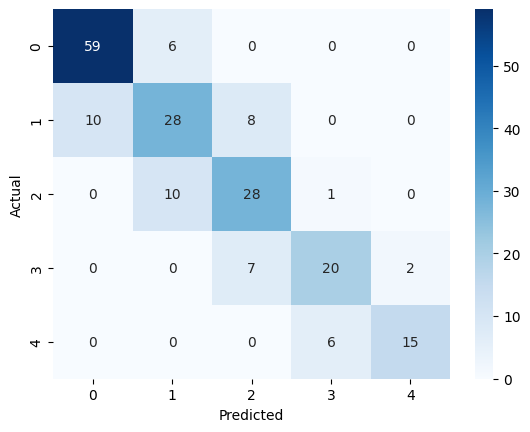

In [197]:
sns.heatmap(confusion_matrix(y_test, y_hat), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')